In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_parquet('data/yellow_tripdata_2023-01.parquet')

# Übungseinheit 2 – Data Cleaning

## 4. Datenbereinigung

### Behandlung fehlender Werte

#### Schritt 1: Analyse fehlender Werte

In [18]:
# Umfassende Analyse der fehlenden Werte
print("="*80)
print("ANALYSE FEHLENDER WERTE")
print("="*80)

# Fehlende Werte pro Spalte
null_analyse = pd.DataFrame({
    'Spalte': df.columns,
    'Fehlende_Werte': df.isnull().sum().values,
    'Prozent': (df.isnull().sum().values / len(df) * 100),
    'Datentyp': df.dtypes.values
})
null_analyse = null_analyse[null_analyse['Fehlende_Werte'] > 0].sort_values('Fehlende_Werte', ascending=False)

print("\nFehlende Werte nach Spalte:")
print(null_analyse.to_string(index=False))

print(f"\nGesamtanzahl fehlender Werte: {df.isnull().sum().sum():,}")
print(f"Durchschnittlicher Anteil fehlender Werte: {(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.2f}%")


ANALYSE FEHLENDER WERTE

Fehlende Werte nach Spalte:
              Spalte  Fehlende_Werte  Prozent Datentyp
     passenger_count           71743  2.33937  float64
          RatecodeID           71743  2.33937  float64
  store_and_fwd_flag           71743  2.33937   object
congestion_surcharge           71743  2.33937  float64
         airport_fee           71743  2.33937  float64

Gesamtanzahl fehlender Werte: 358,715
Durchschnittlicher Anteil fehlender Werte: 0.62%


#### Schritt 2: Klassifizierung fehlender Werte nach Art

In [19]:
# Klassifizierung der Spalten basierend auf fehlenden Werten
print("\n" + "="*80)
print("KLASSIFIZIERUNG VON SPALTEN")
print("="*80)

# Spalten gruppieren nach Art und Anzahl fehlender Werte
spalten_keine_null = [col for col in df.columns if df[col].isnull().sum() == 0]
spalten_wenige_null = [col for col in df.columns if 0 < df[col].isnull().sum() <= len(df) * 0.01]  # <= 1%
spalten_moderate_null = [col for col in df.columns if len(df) * 0.01 < df[col].isnull().sum() <= len(df) * 0.05]  # 1-5%
spalten_viele_null = [col for col in df.columns if df[col].isnull().sum() > len(df) * 0.05]  # > 5%

print(f"\nKeine fehlenden Werte ({len(spalten_keine_null)} Spalten):")
print(f"  {spalten_keine_null}")

print(f"\nWenige fehlende Werte - <= 1% ({len(spalten_wenige_null)} Spalten):")
for col in spalten_wenige_null:
    print(f"  {col}: {df[col].isnull().sum():,} ({df[col].isnull().sum() / len(df) * 100:.2f}%)")

print(f"\nModerate fehlende Werte - 1-5% ({len(spalten_moderate_null)} Spalten):")
for col in spalten_moderate_null:
    print(f"  {col}: {df[col].isnull().sum():,} ({df[col].isnull().sum() / len(df) * 100:.2f}%)")

print(f"\nViele fehlende Werte - > 5% ({len(spalten_viele_null)} Spalten):")
for col in spalten_viele_null:
    print(f"  {col}: {df[col].isnull().sum():,} ({df[col].isnull().sum() / len(df) * 100:.2f}%)")



KLASSIFIZIERUNG VON SPALTEN

Keine fehlenden Werte (14 Spalten):
  ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']

Wenige fehlende Werte - <= 1% (0 Spalten):

Moderate fehlende Werte - 1-5% (5 Spalten):
  passenger_count: 71,743 (2.34%)
  RatecodeID: 71,743 (2.34%)
  store_and_fwd_flag: 71,743 (2.34%)
  congestion_surcharge: 71,743 (2.34%)
  airport_fee: 71,743 (2.34%)

Viele fehlende Werte - > 5% (0 Spalten):


#### Schritt 3: Strategie für fehlende Werte

In [20]:
print("\n" + "="*80)
print("STRATEGIE FÜR FEHLENDE WERTE")
print("="*80)

strategie = {
    'Spalten_löschen': {
        'bedingung': 'Fehlende Werte > 30%',
        'aktion': 'Spalte komplett entfernen',
        'grund': 'Zu viele fehlende Werte, geringe Aussagekraft',
        'spalten': [col for col in spalten_viele_null if df[col].isnull().sum() / len(df) > 0.30]
    },
    'Zeilen_löschen': {
        'bedingung': 'Kritische Spalten mit fehlenden Werten',
        'aktion': 'Zeilen mit fehlenden Werten löschen',
        'grund': 'Kritische Informationen fehlen (z.B. Fahrtpreis, Distanz)',
        'spalten': [col for col in ['fare_amount', 'trip_distance', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
                    if col in df.columns and df[col].isnull().sum() > 0]
    },
    'Imputation_Median': {
        'bedingung': 'Numerische Spalten mit < 5% fehlenden Werten',
        'aktion': 'Mit Median impute',
        'grund': 'Robust gegen Ausreißer, bewahrt Verteilung',
        'spalten': [col for col in spalten_wenige_null + spalten_moderate_null
                   if df[col].dtype in ['float64', 'int64'] and col not in ['fare_amount', 'trip_distance']]
    },
    'Imputation_Modus': {
        'bedingung': 'Kategorische Spalten mit < 5% fehlenden Werten',
        'aktion': 'Mit Modus impute',
        'grund': 'Häufigster Wert ist beste Schätzung',
        'spalten': [col for col in spalten_wenige_null + spalten_moderate_null
                   if df[col].dtype == 'object']
    },
    'Imputation_Vorwärts': {
        'bedingung': 'Zeitreihen/Sequenzdaten',
        'aktion': 'Forward Fill oder Backward Fill',
        'grund': 'Zeitlich konsistente Werte',
        'spalten': []
    }
}

for strategie_typ, details in strategie.items():
    print(f"\n{strategie_typ.upper()}")
    print(f"  Bedingung: {details['bedingung']}")
    print(f"  Aktion: {details['aktion']}")
    print(f"  Grund: {details['grund']}")
    print(f"  Betroffene Spalten: {details['spalten'] if details['spalten'] else 'Keine'}")



STRATEGIE FÜR FEHLENDE WERTE

SPALTEN_LÖSCHEN
  Bedingung: Fehlende Werte > 30%
  Aktion: Spalte komplett entfernen
  Grund: Zu viele fehlende Werte, geringe Aussagekraft
  Betroffene Spalten: Keine

ZEILEN_LÖSCHEN
  Bedingung: Kritische Spalten mit fehlenden Werten
  Aktion: Zeilen mit fehlenden Werten löschen
  Grund: Kritische Informationen fehlen (z.B. Fahrtpreis, Distanz)
  Betroffene Spalten: Keine

IMPUTATION_MEDIAN
  Bedingung: Numerische Spalten mit < 5% fehlenden Werten
  Aktion: Mit Median impute
  Grund: Robust gegen Ausreißer, bewahrt Verteilung
  Betroffene Spalten: ['passenger_count', 'RatecodeID', 'congestion_surcharge', 'airport_fee']

IMPUTATION_MODUS
  Bedingung: Kategorische Spalten mit < 5% fehlenden Werten
  Aktion: Mit Modus impute
  Grund: Häufigster Wert ist beste Schätzung
  Betroffene Spalten: ['store_and_fwd_flag']

IMPUTATION_VORWÄRTS
  Bedingung: Zeitreihen/Sequenzdaten
  Aktion: Forward Fill oder Backward Fill
  Grund: Zeitlich konsistente Werte
  Betrof

#### Schritt 4: Implementierung der Strategie

In [21]:
# Kopie des DataFrames für Bereinigung
df_clean = df.copy()

# 1. Spalten löschen (> 30% fehlend)
spalten_zu_loeschen = [col for col in df.columns if df[col].isnull().sum() / len(df) > 0.30]
if spalten_zu_loeschen:
    print(f"\n1. Lösche Spalten mit > 30% fehlenden Werten: {spalten_zu_loeschen}")
    df_clean = df_clean.drop(columns=spalten_zu_loeschen)
else:
    print("\n1. Keine Spalten mit > 30% fehlenden Werten vorhanden.")

# 2. Zeilen löschen (kritische Spalten)
kritische_spalten = [col for col in ['fare_amount', 'trip_distance', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
                     if col in df_clean.columns]
zeilen_vor = len(df_clean)
df_clean = df_clean.dropna(subset=kritische_spalten)
zeilen_geloescht = zeilen_vor - len(df_clean)
print(f"\n2. Gelöschte Zeilen mit fehlenden kritischen Werten: {zeilen_geloescht:,} ({zeilen_geloescht/zeilen_vor*100:.2f}%)")

# 3. Numerische Spalten: Median-Imputation
numerische_spalten_mit_null = [col for col in df_clean.columns
                               if df_clean[col].dtype in ['float64', 'int64'] and df_clean[col].isnull().sum() > 0]
if numerische_spalten_mit_null:
    print(f"\n3. Impute numerische Spalten mit Median:")
    for col in numerische_spalten_mit_null:
        median_wert = df_clean[col].median()
        null_count = df_clean[col].isnull().sum()
        df_clean[col].fillna(median_wert, inplace=True)
        print(f"   {col}: {null_count:,} Werte mit Median {median_wert:.2f} impute")

# 4. Kategorische Spalten: Modus-Imputation
kategorische_spalten_mit_null = [col for col in df_clean.columns
                                 if df_clean[col].dtype == 'object' and df_clean[col].isnull().sum() > 0]
if kategorische_spalten_mit_null:
    print(f"\n4. Impute kategorische Spalten mit Modus:")
    for col in kategorische_spalten_mit_null:
        modus_wert = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
        null_count = df_clean[col].isnull().sum()
        df_clean[col].fillna(modus_wert, inplace=True)
        print(f"   {col}: {null_count:,} Werte mit '{modus_wert}' impute")

# Verifikation
print("\n" + "="*80)
print("VERIFIKATION NACH BEREINIGUNG")
print("="*80)
remaining_null = df_clean.isnull().sum().sum()
print(f"\nVerbleibende fehlende Werte: {remaining_null:,}")
print(f"Originaldatensatz: {len(df):,} Zeilen × {len(df.columns)} Spalten")
print(f"Bereinigter Datensatz: {len(df_clean):,} Zeilen × {len(df_clean.columns)} Spalten")
print(f"Entfernte Zeilen: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean)) / len(df) * 100:.2f}%)")
print(f"Entfernte Spalten: {len(df.columns) - len(df_clean.columns)}")



1. Keine Spalten mit > 30% fehlenden Werten vorhanden.

2. Gelöschte Zeilen mit fehlenden kritischen Werten: 0 (0.00%)

3. Impute numerische Spalten mit Median:
   passenger_count: 71,743 Werte mit Median 1.00 impute
   RatecodeID: 71,743 Werte mit Median 1.00 impute
   congestion_surcharge: 71,743 Werte mit Median 2.50 impute
   airport_fee: 71,743 Werte mit Median 0.00 impute

4. Impute kategorische Spalten mit Modus:


/var/folders/0q/dbjt5wt508l2y1qwnllcp5hc0000gn/T/ipykernel_47045/1334269437.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_wert, inplace=True)
/var/folders/0q/dbjt5wt508l2y1qwnllcp5hc0000gn/T/ipykernel_47045/1334269437.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

   store_and_fwd_flag: 71,743 Werte mit 'N' impute

VERIFIKATION NACH BEREINIGUNG

Verbleibende fehlende Werte: 0
Originaldatensatz: 3,066,766 Zeilen × 19 Spalten
Bereinigter Datensatz: 3,066,766 Zeilen × 19 Spalten
Entfernte Zeilen: 0 (0.00%)
Entfernte Spalten: 0


#### Schritt 5: Visualisierung der Veränderungen

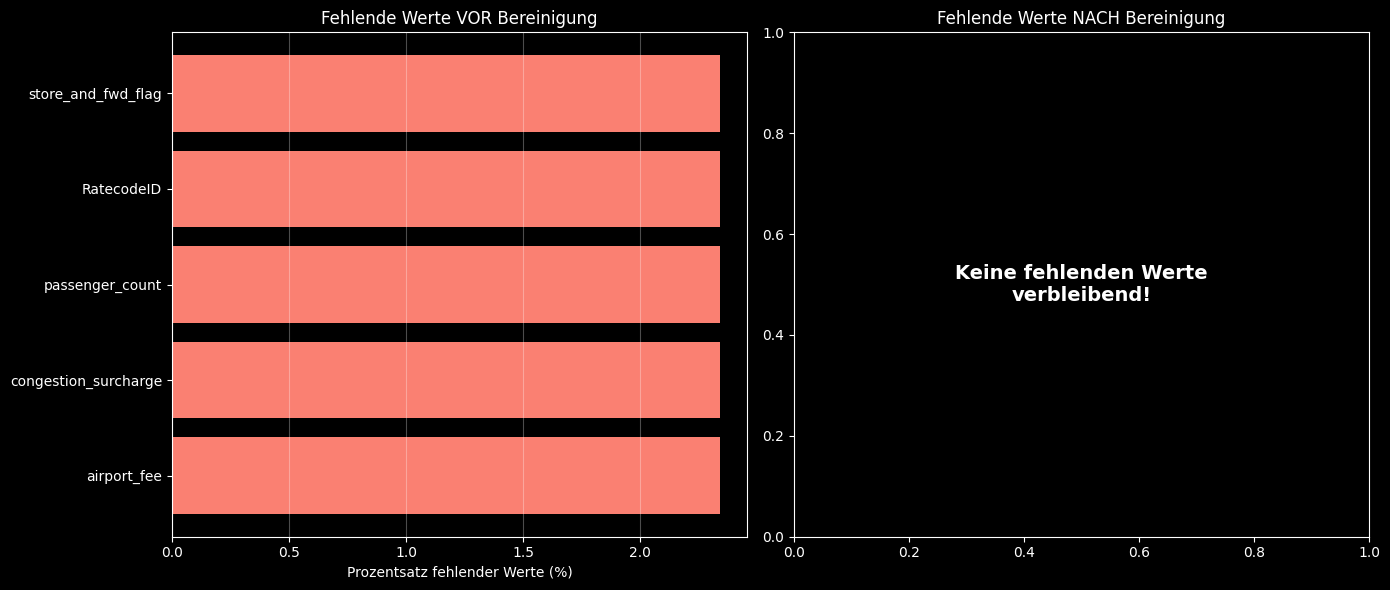


Visualisierung erstellt: Vergleich fehlende Werte vorher/nachher


In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vorher
null_vorher = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_vorher = null_vorher[null_vorher > 0]
axes[0].barh(range(len(null_vorher)), null_vorher.values, color='salmon')
axes[0].set_yticks(range(len(null_vorher)))
axes[0].set_yticklabels(null_vorher.index)
axes[0].set_xlabel('Prozentsatz fehlender Werte (%)')
axes[0].set_title('Fehlende Werte VOR Bereinigung')
axes[0].grid(axis='x', alpha=0.3)

# Nachher
null_nachher = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)
null_nachher = null_nachher[null_nachher > 0]
if len(null_nachher) > 0:
    axes[1].barh(range(len(null_nachher)), null_nachher.values, color='lightgreen')
    axes[1].set_yticks(range(len(null_nachher)))
    axes[1].set_yticklabels(null_nachher.index)
    axes[1].set_xlabel('Prozentsatz fehlender Werte (%)')
    axes[1].set_title('Fehlende Werte NACH Bereinigung')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Keine fehlenden Werte\nverbleibend!',
                ha='center', va='center', fontsize=14, fontweight='bold',
                transform=axes[1].transAxes)
    axes[1].set_title('Fehlende Werte NACH Bereinigung')

plt.tight_layout()
plt.show()

print("\nVisualisierung erstellt: Vergleich fehlende Werte vorher/nachher")
